# Bridge contextual gene-essentiality benchmark

This notebook is a view over saved, out-of-fold results. Computation lives in `pipeline/`; no metric is hard-coded here.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display
ROOT = Path.cwd()
if ROOT.name != 'gene_essentiality':
    ROOT = ROOT / 'benchmarks' / 'gene_essentiality'
RESULTS = ROOT / 'results'
assert (RESULTS / 'primary_metrics.csv').exists()


## Cohort and protocol

The matched benchmark contains 1,108 cell lines and 14,415 dependency genes. Ten-fold cell-line cross-validation produces one out-of-fold prediction for every cell line. Mean PCC is the unweighted mean of per-gene correlations across cell lines. PCA is fitted on training lines only.

In [2]:
audit = pd.read_json(RESULTS / 'dataset_audit.json', typ='series')
metrics = pd.read_csv(RESULTS / 'primary_metrics.csv')
display(metrics.style.format({
    'mean_pcc': '{:.5f}', 'median_pcc': '{:.5f}',
    'mean_scc': '{:.5f}', 'median_scc': '{:.5f}'
}))

,representation,gene_count,evaluable_pcc,mean_pcc,median_pcc,mean_scc,median_scc,fraction_pcc_positive
0,bridge_contextual,14415,14415,0.01456,0.00861,0.01254,0.00741,0.566285
1,bridge_plus_pca,14415,14415,0.01537,0.00939,0.01294,0.00835,0.581686
2,bulkformer_contextual,14415,14415,0.01775,0.01037,0.01562,0.01010,0.599723
3,bulkformer_native,17525,17525,0.01419,0.00802,0.01248,0.00752,0.576776
4,pca_context,14415,14415,0.01307,0.01091,0.00805,0.00765,0.587790
5,target_expression,14415,14415,0.01864,0.01098,0.01149,0.00917,0.578425


## Paired gene-level diagnostics

In [3]:
paired = pd.read_csv(RESULTS / 'analysis' / 'paired_comparisons.csv')
display(paired.style.format({
    c: '{:.5f}' for c in paired.columns if c != 'comparison' and c != 'n_genes'
}))

,comparison,n_genes,mean_delta_pcc,median_delta_pcc,ci95_mean_low,ci95_mean_high,fraction_left_greater,fraction_right_greater,paired_sign_flip_p
0,bridge_contextual_minus_bulkformer_contextual,14415,-0.00319,-0.00227,-0.00431,-0.00212,0.48484,0.51516,0.00001
1,bridge_contextual_minus_pca_context,14415,0.00150,-0.00303,0.00017,0.00284,0.47950,0.52050,0.02842
2,bridge_contextual_minus_target_expression,14415,-0.00407,-0.00497,-0.00554,-0.00260,0.47256,0.52744,0.00001
3,bridge_plus_pca_minus_bridge_contextual,14415,0.00081,0.00125,0.00025,0.00137,0.51474,0.48526,0.00544
4,bridge_plus_pca_minus_pca_context,14415,0.00231,-0.00326,0.00102,0.00362,0.48186,0.51814,0.00053
5,bulkformer_contextual_minus_target_expression,14415,-0.00089,-0.00335,-0.00226,0.00052,0.47804,0.52196,0.20726


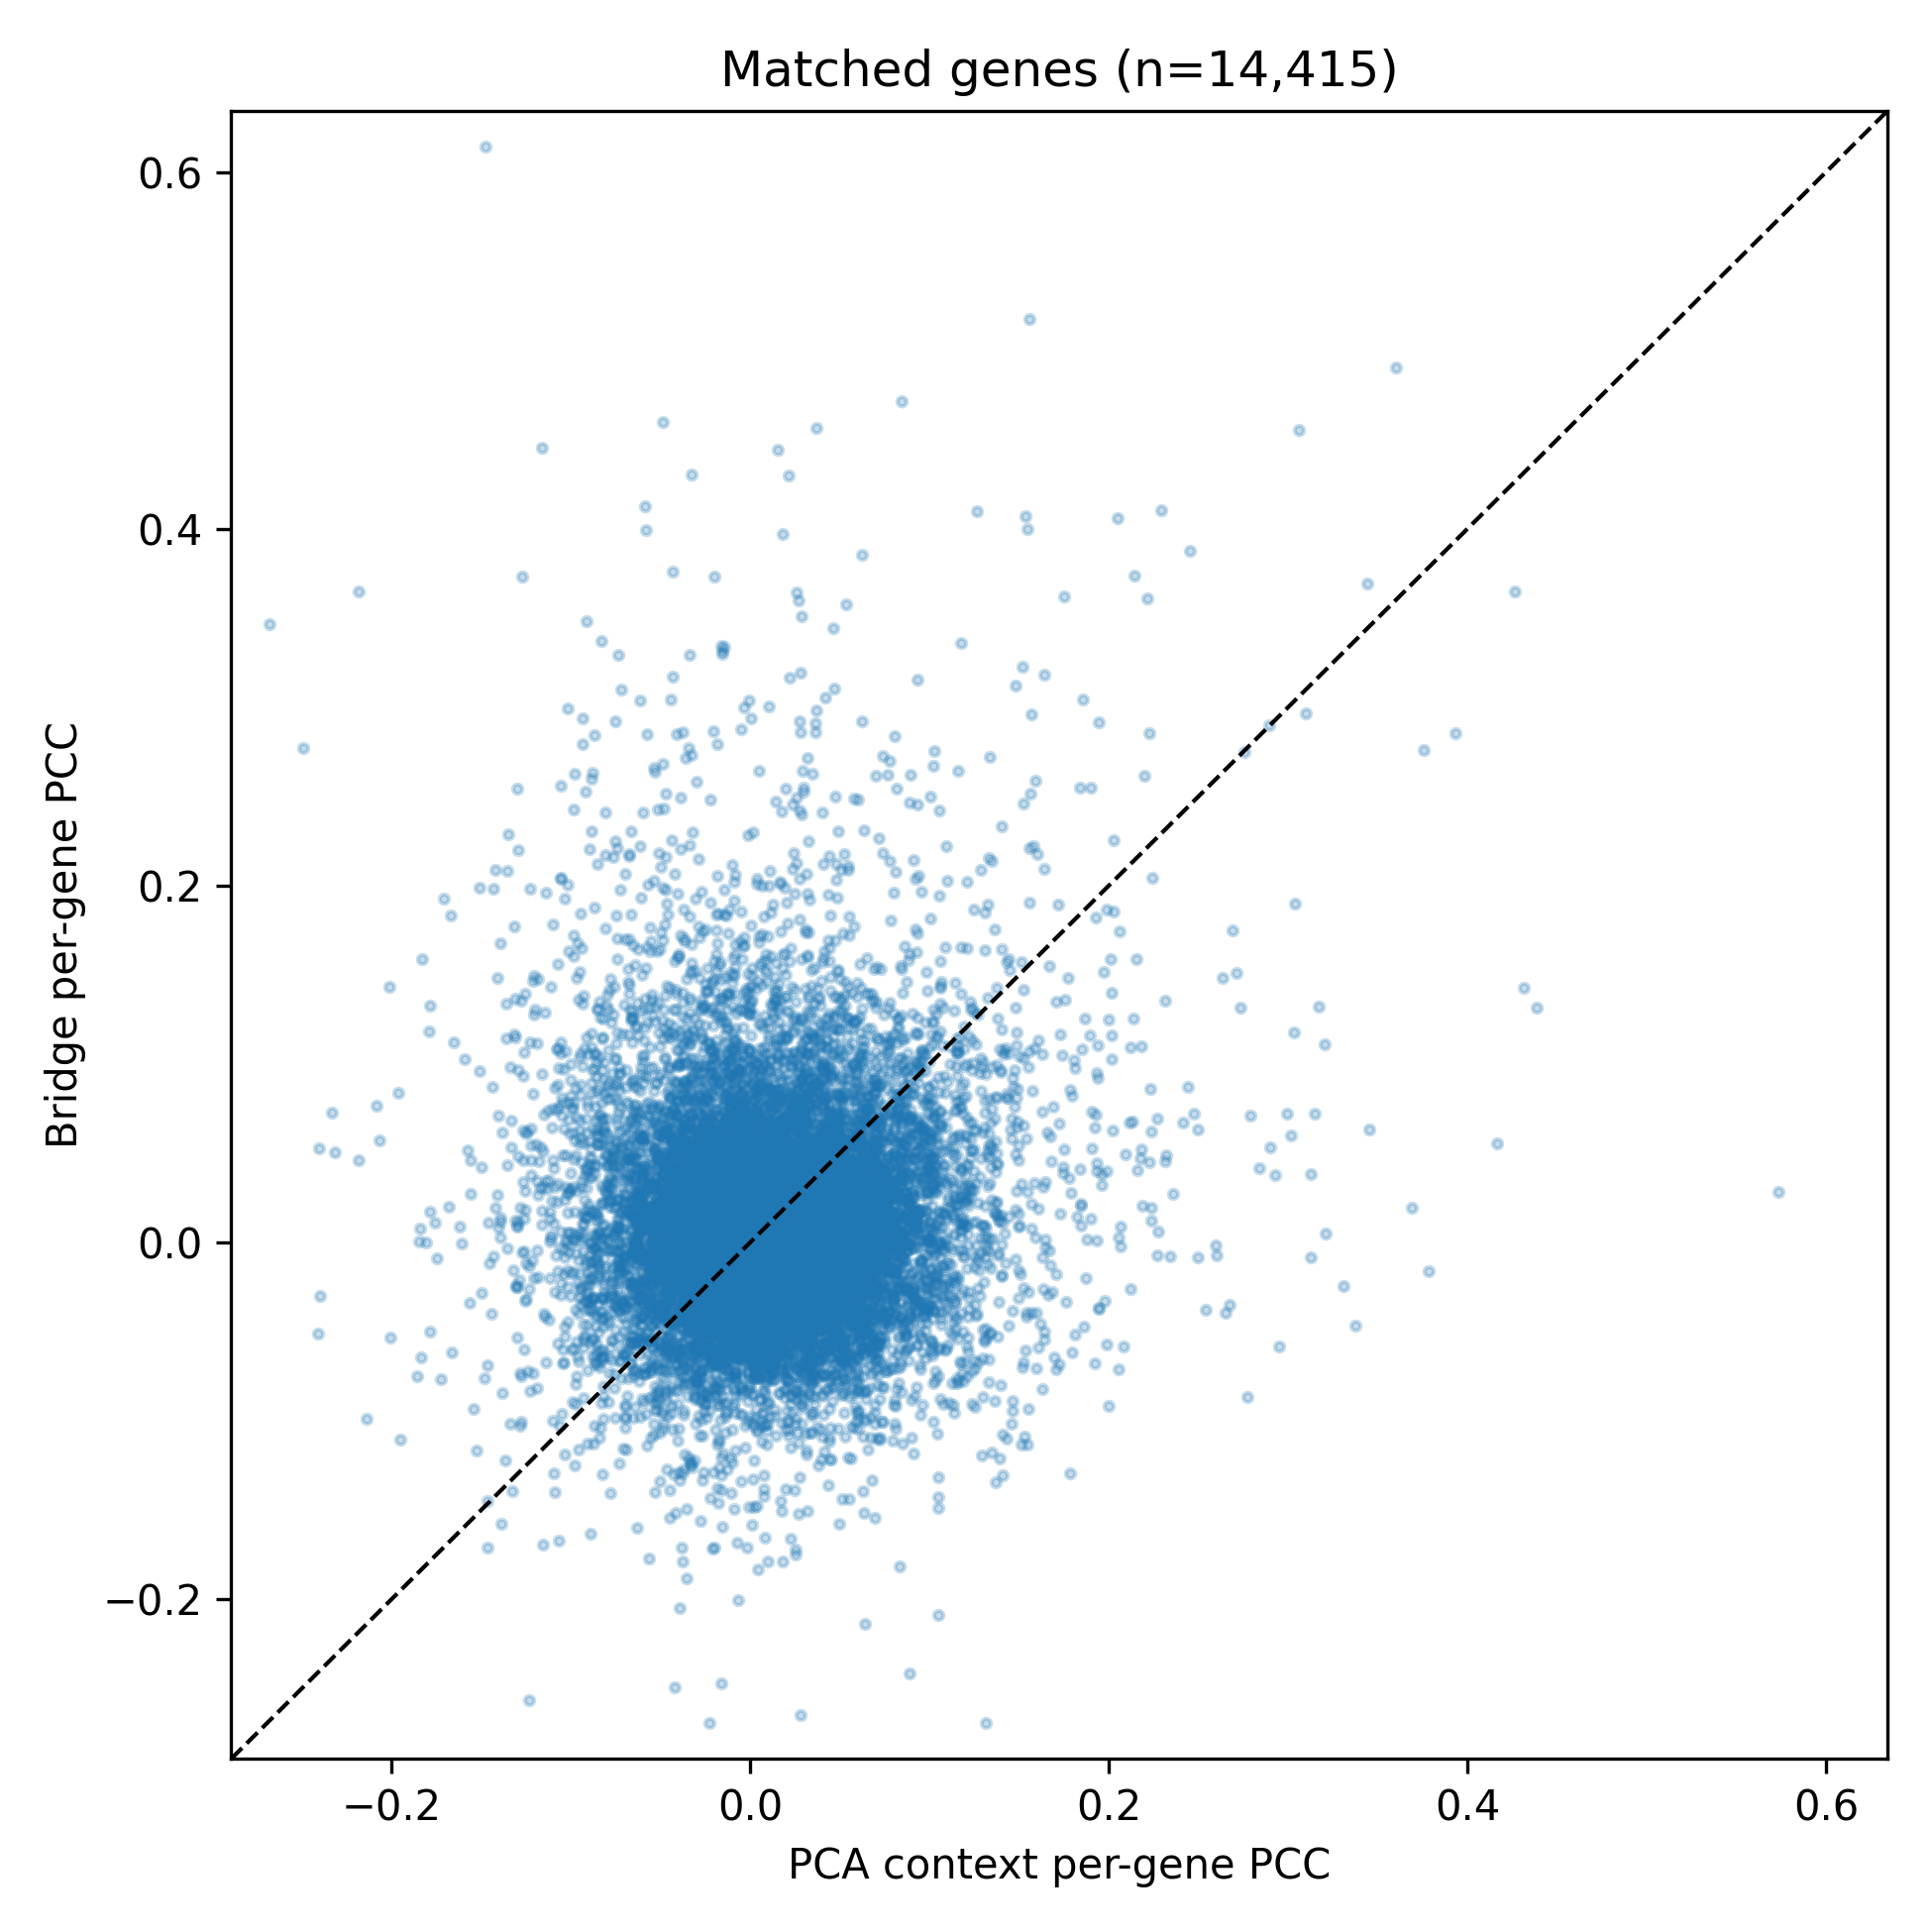

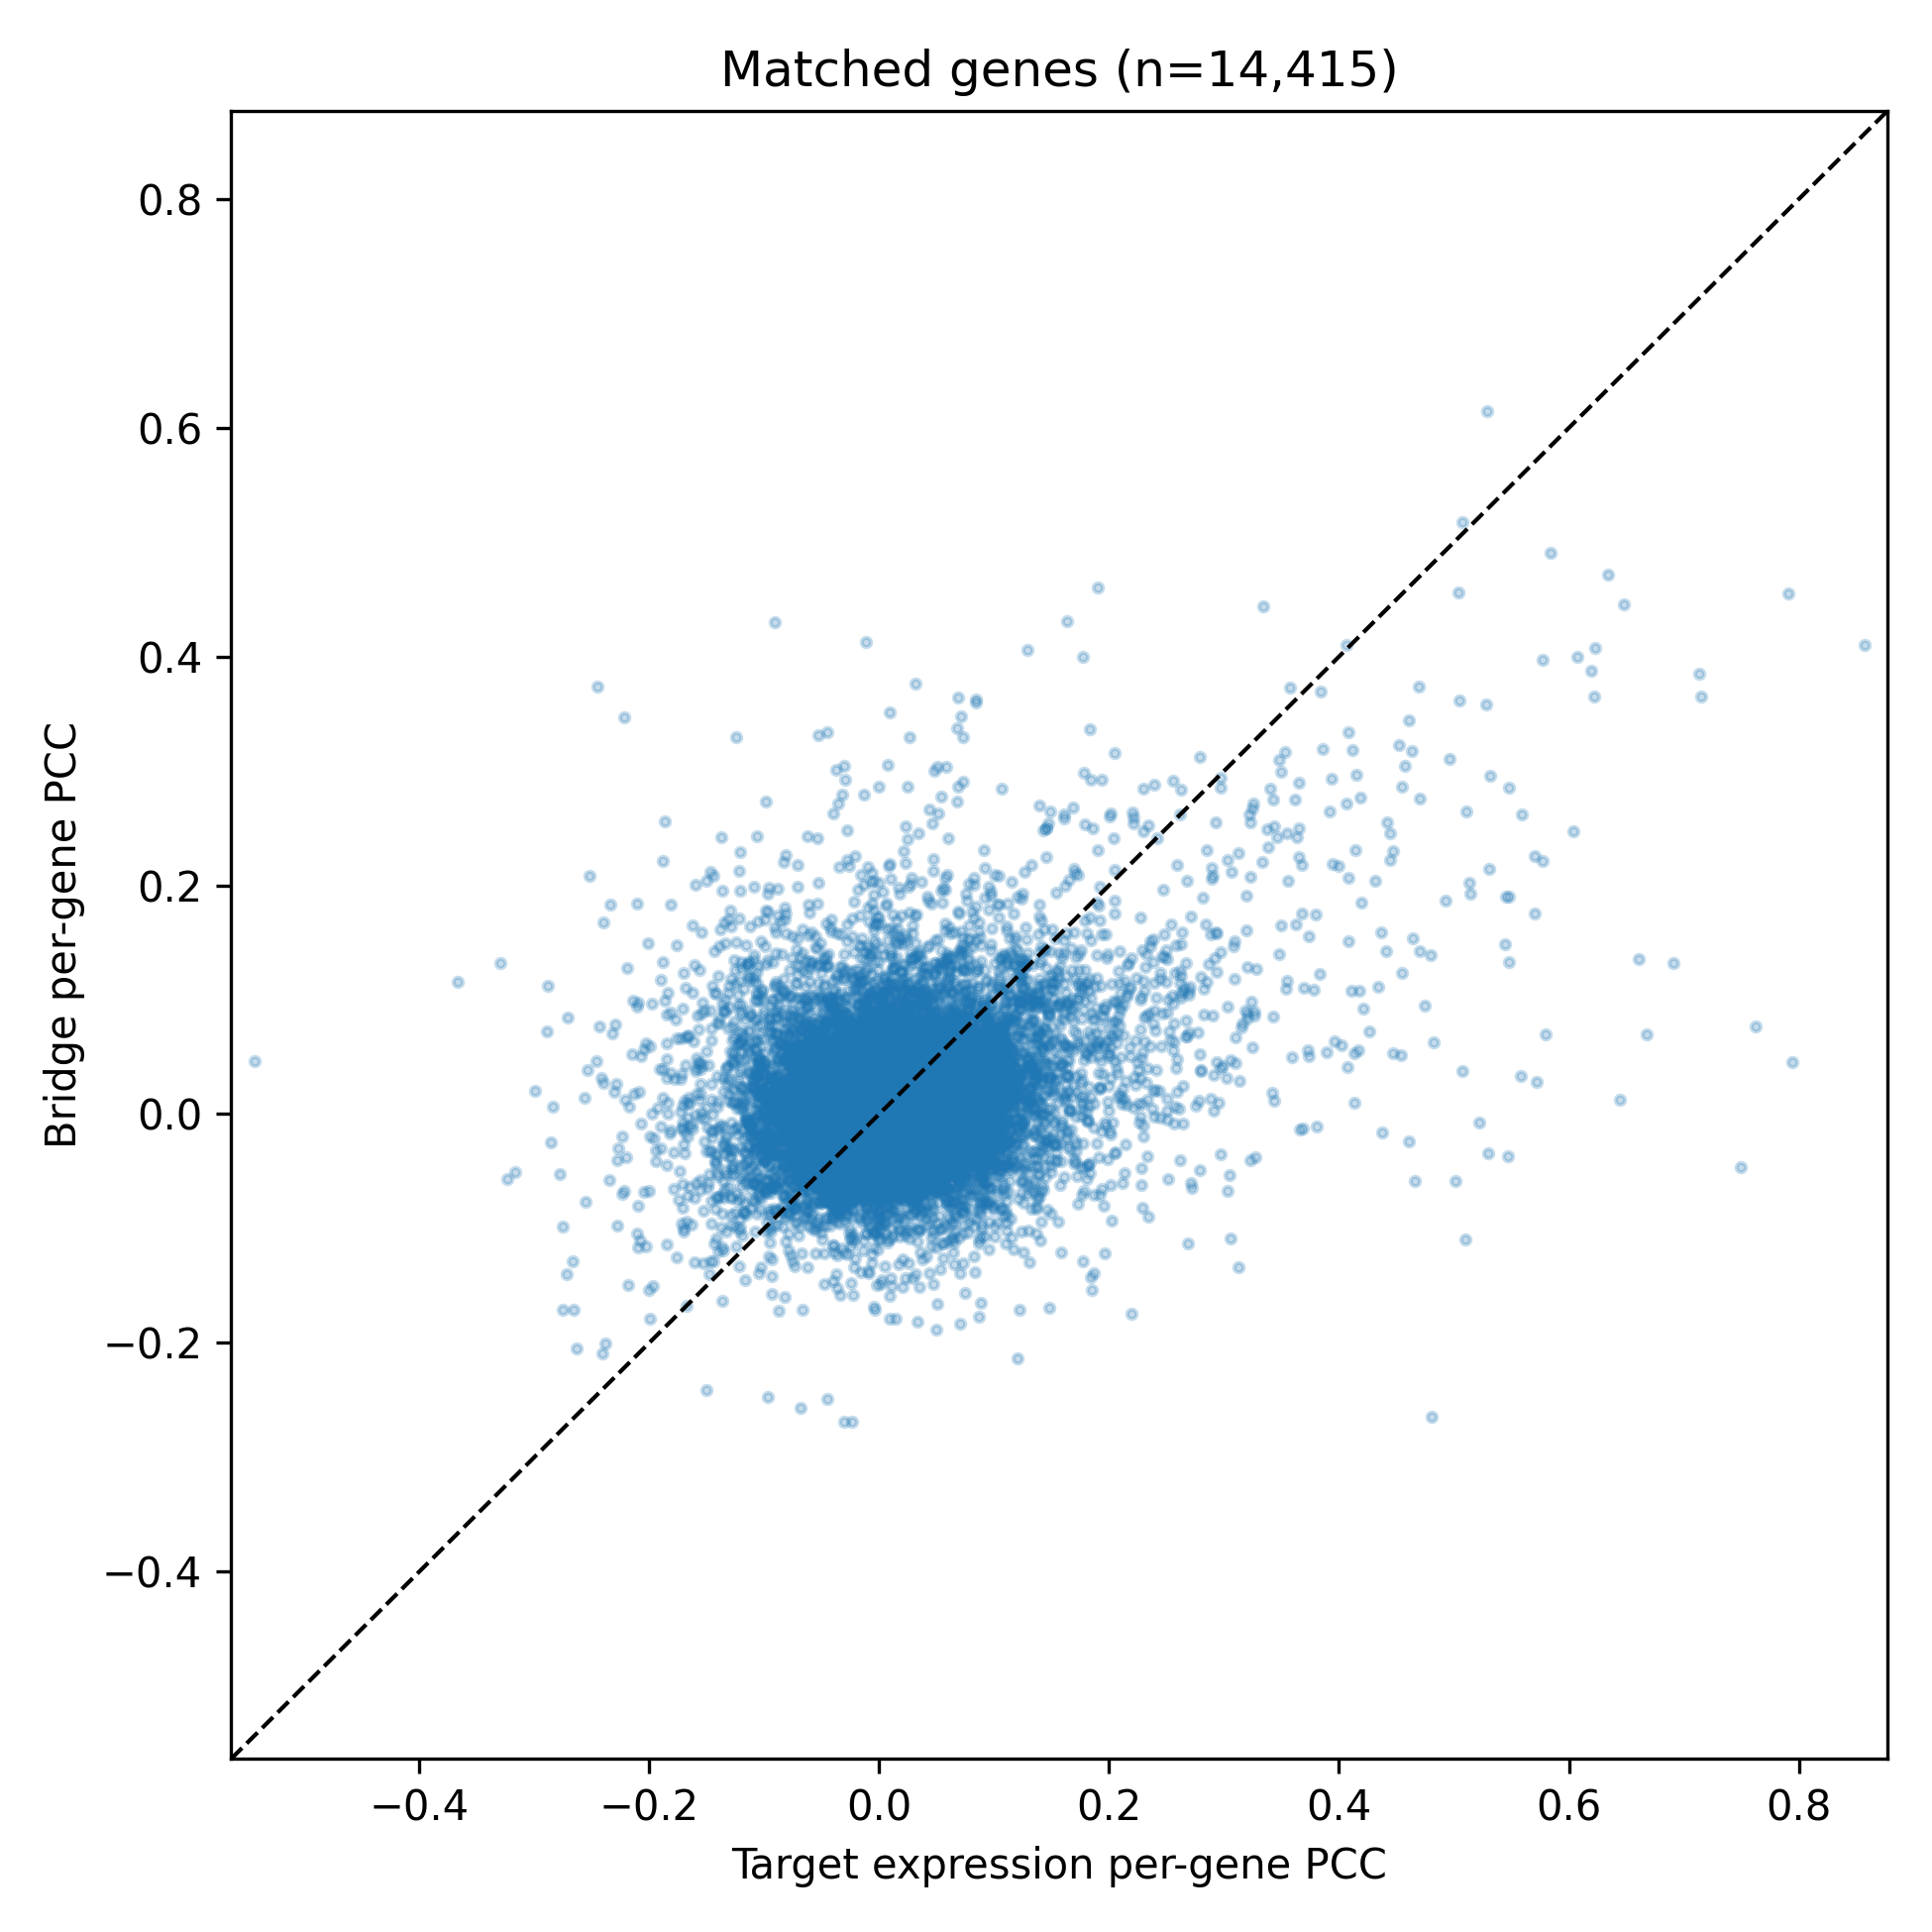

In [4]:
display(Image(filename=str(RESULTS / 'figures' / 'bridge_vs_pca_pcc.png'), width=760))
display(Image(filename=str(RESULTS / 'figures' / 'bridge_vs_target_expression_pcc.png'), width=760))

## Conclusion

Bridge contextual tokens contain weak predictive signal but do not beat target-gene expression. Bridge is slightly above PCA in mean PCC, while its median paired difference is negative and only 47.95% of genes favor Bridge. Bridge + PCA improves mean PCC slightly, indicating limited complementarity. The published BulkFormer value of 0.186 is retained as external context because its exact evaluation procedure could not be recovered.

In [5]:
variance = pd.read_csv(RESULTS / 'analysis' / 'variance_control_correlations.csv')
display(variance)

,representation,metric,covariate,spearman_correlation
0,bridge_contextual,pcc,train_expression_mean,0.104281
1,bridge_contextual,pcc,train_expression_variance,0.000743
2,bridge_contextual,pcc,train_dependency_variance,0.180174
3,bridge_contextual,scc,train_expression_mean,0.106219
4,bridge_contextual,scc,train_expression_variance,-0.011290
5,bridge_contextual,scc,train_dependency_variance,0.178214
6,bridge_plus_pca,pcc,train_expression_mean,0.110648
7,bridge_plus_pca,pcc,train_expression_variance,0.014453
8,bridge_plus_pca,pcc,train_dependency_variance,0.171471
9,bridge_plus_pca,scc,train_expression_mean,0.111014
